In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-02-11 11:41:10--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-11 11:41:10 ERROR 404: Not Found.



In [3]:
!unzip fruits.zip

unzip:  cannot find or open fruits.zip, fruits.zip.zip or fruits.zip.ZIP.


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [5]:
tf.__version__

'2.19.0'

In [9]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


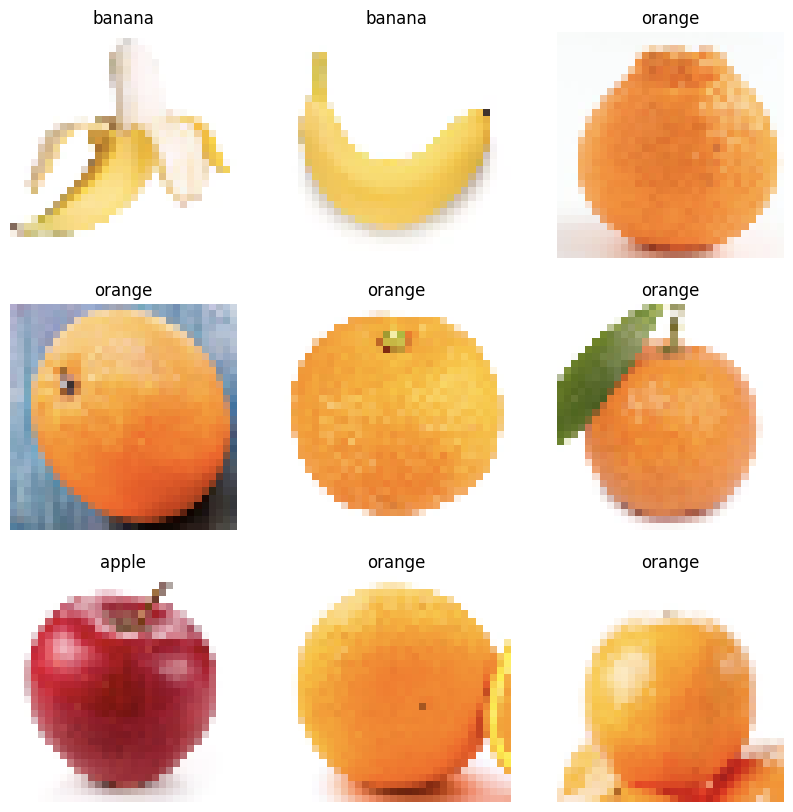

In [10]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [11]:
model = tf.keras.Sequential(
    [
     tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(64, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(128, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation="softmax"),
     tf.keras.layers.Dense(3)
    ]
)

In [12]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

In [13]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.3180 - loss: 1.0990 - val_accuracy: 0.3485 - val_loss: 1.0893
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.4201 - loss: 1.0788 - val_accuracy: 0.5455 - val_loss: 1.0376
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.4996 - loss: 1.0307 - val_accuracy: 0.6212 - val_loss: 0.9778
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.6057 - loss: 0.9828 - val_accuracy: 0.6212 - val_loss: 0.9641
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.6449 - loss: 0.9666 - val_accuracy: 0.6667 - val_loss: 0.9600
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.6926 - loss: 0.9453 - val_accuracy: 0.6818 - val_loss: 0.9245
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.7820 - loss: 0.9126 - val_accuracy: 0.7576 - val_loss: 0.9116
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.7815 - loss: 0.8950 - val_accuracy: 0.72

In [14]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9207 - loss: 0.6223


[0.6100444793701172, 0.9384615421295166]

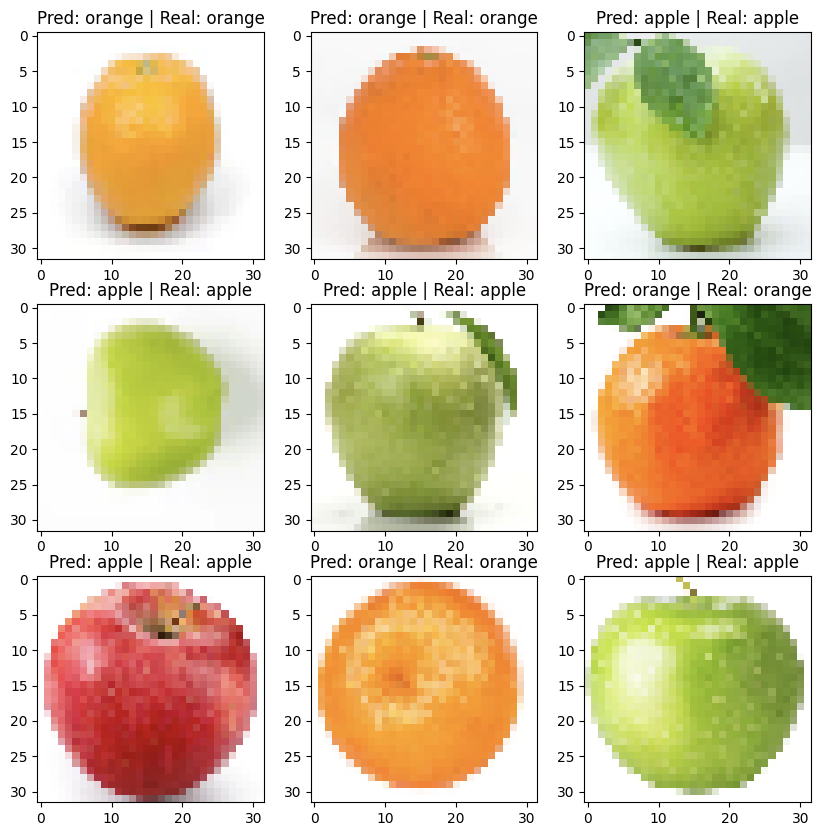

In [15]:
import numpy

plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
  classifications = model(images)
  # print(classifications)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpry733yr_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138842727120144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842727120720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842727119184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671271376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671270992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671271952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671270800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671272912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671272336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138842671273872: TensorSpec(shape=(), dtype=tf.resource, name=None)
